In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Конфигурация сетки 2x2 ---
# 12 отрезков, кодируемых буквами
LETTERS = ['u', 'w', 'i', 'a', 'n', 'm', 'p', 'b', 'o', 'e', 'q', 'd']
letter_to_idx = {ch: i for i, ch in enumerate(LETTERS)}
idx_to_letter = {i: ch for i, ch in enumerate(LETTERS)}

# 12 отрезков (индексы 0..11), порядок фиксирован
EDGES = [
    ((0, 0), (1, 0)),  # 0: u - нижний левый горизонтальный
    ((1, 0), (2, 0)),  # 1: w - нижний правый горизонтальный
    ((0, 1), (1, 1)),  # 2: i - средний левый горизонтальный (внутр. левый)
    ((1, 1), (2, 1)),  # 3: a - средний правый горизонтальный (внутр. правый)
    ((0, 2), (1, 2)),  # 4: n - верхний левый горизонтальный
    ((1, 2), (2, 2)),  # 5: m - верхний правый горизонтальный
    ((0, 0), (0, 1)),  # 6: p - левый нижний вертикальный
    ((0, 1), (0, 2)),  # 7: b - левый верхний вертикальный
    ((1, 0), (1, 1)),  # 8: o - средний нижний вертикальный (внутр. нижний)
    ((1, 1), (1, 2)),  # 9: e - средний верхний вертикальный (внутр. верхний)
    ((2, 0), (2, 1)),  # 10: q - правый нижний вертикальный
    ((2, 1), (2, 2)),  # 11: d - правый верхний вертикальный
]


# Вектор направления для каждого отрезка: dx,dy = 2*(середина - центр(1,1))
def _midpoint(p1, p2):
    return ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)


VECTORS = []
for p1, p2 in EDGES:
    mx, my = _midpoint(p1, p2)
    dx = int(2 * (mx - 1))
    dy = int(2 * (my - 1))
    VECTORS.append((dx, dy))

# Построение графа смежности отрезков (общие концы)
adj = {i: set() for i in range(12)}
for i, (a1, a2) in enumerate(EDGES):
    for j, (b1, b2) in enumerate(EDGES):
        if i >= j:
            continue
        if a1 == b1 or a1 == b2 or a2 == b1 or a2 == b2:
            adj[i].add(j)
            adj[j].add(i)


# Кратчайшие расстояния в графе отрезков (матрица 12x12)
def bfs_dist(start):
    dist = [None] * 12
    dist[start] = 0
    q = [start]
    for u in q:
        for v in adj[u]:
            if dist[v] is None:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist


DIST_MATRIX = np.array([bfs_dist(i) for i in range(12)], dtype=int)
MAX_DIST = np.max(DIST_MATRIX)  # = 3


# --- Симметрии квадрата (D4) ---
def sym_identity(v):
    return (v[0], v[1])


def sym_rot90(v):
    return (v[1], -v[0])


def sym_rot180(v):
    return (-v[0], -v[1])


def sym_rot270(v):
    return (-v[1], v[0])


def sym_flip_x(v):
    return (-v[0], v[1])


def sym_flip_y(v):
    return (v[0], -v[1])


def sym_flip_d1(v):
    return (v[1], v[0])


def sym_flip_d2(v):
    return (-v[1], -v[0])


SYMMETRIES = [
    sym_identity,
    sym_rot90,
    sym_rot180,
    sym_rot270,
    sym_flip_x,
    sym_flip_y,
    sym_flip_d1,
    sym_flip_d2,
]
SYM_NAMES = ["id", "rot90", "rot180", "rot270", "flipX", "flipY", "flipD1", "flipD2"]
COST = [0, 1, 1, 1, 1, 1, 1, 1]  # штраф за нетождественную симметрию

# Сопоставление индексов отрезков при каждой симметрии
vec_to_idx = {v: i for i, v in enumerate(VECTORS)}
SYMMETRY_MAPPING = []
for f in SYMMETRIES:
    mapping = {}
    for i, v in enumerate(VECTORS):
        new_v = f(v)
        mapping[i] = vec_to_idx[new_v]
    SYMMETRY_MAPPING.append(mapping)

print("Константы загружены. Готово.")

Константы загружены. Готово.


In [3]:
def decode(letter_string: str) -> set:
    """
    Принимает строку из букв (подстрока LETTERS).
    Возвращает множество индексов присутствующих отрезков (0..11).
    """
    result = set()
    for ch in letter_string:
        if ch not in letter_to_idx:
            raise ValueError(f"Недопустимый символ '{ch}'. Допустимые: {LETTERS}")
        result.add(letter_to_idx[ch])
    return result

# Пример
example = 'uwianmpboeqd'
print(f"Фигура: '{example}' -> индексы: {decode(example)}")

Фигура: 'uwianmpboeqd' -> индексы: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}


Визуализация: 'neipuw'


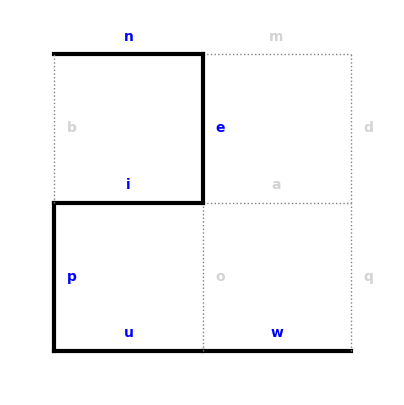

In [5]:
def visualize(letter_string: str, ax=None):
    """
    Визуализация сетки 2x2:
    сплошные линии для присутствующих букв, пунктирные серые для отсутствующих.
    Каждый отрезок подписан своей буквой.
    """
    present = decode(letter_string)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    
    for i, ((x1,y1),(x2,y2)) in enumerate(EDGES):
        # Определяем цвет и стиль линии
        if i in present:
            color = 'black'
            linestyle = '-'
            linewidth = 3
        else:
            color = 'gray'
            linestyle = 'dotted'
            linewidth = 1
        
        # Рисуем линию
        ax.plot([x1,x2], [y1,y2], color=color, linestyle=linestyle, linewidth=linewidth)
        
        # Подписываем букву отрезка
        mx = (x1 + x2) / 2
        my = (y1 + y2) / 2
        
        if y1 == y2:  # горизонтальная линия
            offset_x = 0
            offset_y = 0.12
        else:  # вертикальная линия
            offset_x = 0.12
            offset_y = 0
        
        text_color = 'blue' if i in present else 'lightgray'
        letter = idx_to_letter[i]
        
        ax.text(mx + offset_x, my + offset_y, letter, 
                fontsize=10, ha='center', va='center', 
                color=text_color, fontweight='bold')
    
    ax.set_aspect('equal')
    ax.set_xlim(-0.3, 2.3)
    ax.set_ylim(-0.3, 2.3)
    ax.axis('off')
    ax.set_frame_on(False)
    plt.show()

# Демонстрация
test_str = 'neipuw'
print(f"Визуализация: '{test_str}'")
visualize(test_str)

In [6]:
def h_measure(A_set: set, B_set: set) -> int:
    """
    Внутренняя метрика (без симметрий) на множествах индексов.
    Z = пересечение, D = симметрическая разность.
    Сумма (2 + расстояние от e до Z) для e in D.
    """
    Z = A_set & B_set
    D = A_set ^ B_set
    if not Z:
        return sum(2 + MAX_DIST for _ in D)
    z_list = list(Z)
    total = 0
    for e in D:
        d_min = min(DIST_MATRIX[e, f] for f in z_list)
        total += 2 + d_min
    return total

def compare(str1: str, str2: str) -> int:
    """
    Итоговый коэффициент непохожести.
    Минимум по 8 симметриям: cost(σ) + h(σ(A), B).
    Принимает строки из букв (подстроки uwianmpboeqd).
    """
    A = decode(str1)
    B = decode(str2)
    best = 10**9
    for sigma, mapping in enumerate(SYMMETRY_MAPPING):
        sigma_A = {mapping[i] for i in A}
        total = COST[sigma] + h_measure(sigma_A, B)
        if total < best:
            best = total
    return best

# Примеры
s1 = 'uwianmpboeqd'  # все отрезки
s2 = 'wianmpboeqd'   # не хватает 'u' (нижний левый горизонтальный)
print(f"compare('{s1}', '{s2}') = {compare(s1, s2)}")

# Поворот
s3 = 'ianmpboe'
s4 = 'uwianmpb'
print(f"Сравнение возможных поворотов: {compare(s3, s4)}")

compare('uwianmpboeqd', 'wianmpboeqd') = 3
Сравнение возможных поворотов: 13


In [8]:
def compare_benchmark(reference: str, samples: list, label: str = ""):
    """
    Сравнивает эталонную строку reference с каждым образцом из samples.
    Выводит результаты в читаемом формате.
    """
    print("=" * 60)
    if label:
        print(f"СРАВНЕНИЕ: '{reference}' vs {label}")
    else:
        print(f"СРАВНЕНИЕ: '{reference}' vs образцы")
    print("=" * 60)
    
    for s in samples:
        d = compare(reference, s)
        print(f"  '{reference}' vs '{s}' -> коэффициент = {d}")
    print()


# =====================================================
# Вспомогательные генераторы строк
# =====================================================
def generate_single_letter_strings():
    """Генерирует все строки с ровно одной буквой"""
    return [[ch] for ch in LETTERS]
    # Но нам нужны строки, а не списки

def generate_all_but_one_strings():
    """Генерирует все строки, где отсутствует ровно одна буква"""
    all_letters = 'uwianmpboeqd'
    return [all_letters.replace(ch, '') for ch in LETTERS]

def generate_growing_letters():
    """Генерирует строки с нарастающим числом букв (u, uw, uwi, ...)"""
    all_letters = 'uwianmpboeqd'
    return [all_letters[:i] for i in range(1, 13)]


# =====================================================
# Запуск сравнений
# =====================================================
empty_str = ""
full_str  = 'uwianmpboeqd'
single_letters = generate_single_letter_strings()
all_but_one = generate_all_but_one_strings()
growing = generate_growing_letters()

# 1. Пустая строка vs коды с одной буквой
compare_benchmark(empty_str, single_letters, "коды с одной буквой")

# 2. Пустая строка vs коды без одной буквы (все кроме одной)
compare_benchmark(empty_str, all_but_one, "коды без одной буквы")

# 3. Пустая строка vs нарастающие буквы
compare_benchmark(empty_str, growing, "нарастающие буквы")

# 4. Полная строка vs коды с одной буквой
compare_benchmark(full_str, single_letters, "коды с одной буквой")

# 5. Полная строка vs коды без одной буквы
compare_benchmark(full_str, all_but_one, "коды без одной буквы")

# 6. Полная строка vs нарастающие буквы
compare_benchmark(full_str, growing, "нарастающие буквы")


СРАВНЕНИЕ: '' vs коды с одной буквой
  '' vs '['u']' -> коэффициент = 5
  '' vs '['w']' -> коэффициент = 5
  '' vs '['i']' -> коэффициент = 5
  '' vs '['a']' -> коэффициент = 5
  '' vs '['n']' -> коэффициент = 5
  '' vs '['m']' -> коэффициент = 5
  '' vs '['p']' -> коэффициент = 5
  '' vs '['b']' -> коэффициент = 5
  '' vs '['o']' -> коэффициент = 5
  '' vs '['e']' -> коэффициент = 5
  '' vs '['q']' -> коэффициент = 5
  '' vs '['d']' -> коэффициент = 5

СРАВНЕНИЕ: '' vs коды без одной буквы
  '' vs 'wianmpboeqd' -> коэффициент = 55
  '' vs 'uianmpboeqd' -> коэффициент = 55
  '' vs 'uwanmpboeqd' -> коэффициент = 55
  '' vs 'uwinmpboeqd' -> коэффициент = 55
  '' vs 'uwiampboeqd' -> коэффициент = 55
  '' vs 'uwianpboeqd' -> коэффициент = 55
  '' vs 'uwianmboeqd' -> коэффициент = 55
  '' vs 'uwianmpoeqd' -> коэффициент = 55
  '' vs 'uwianmpbeqd' -> коэффициент = 55
  '' vs 'uwianmpboqd' -> коэффициент = 55
  '' vs 'uwianmpboed' -> коэффициент = 55
  '' vs 'uwianmpboeq' -> коэффициент = 55


In [ ]:
import math
from itertools import combinations


def combinations_count(n, k):
    """Возвращает число сочетаний C(n, k)"""
    return math.factorial(n) // (math.factorial(k) * math.factorial(n - k))


def generate_all_combinations_letters(k):
    """
    Генерирует все строки из 12 букв с ровно k буквами.
    Возвращает список строк из букв.
    """
    result = []
    for letter_indices in combinations(range(12), k):
        s = ''.join(idx_to_letter[i] for i in sorted(letter_indices))
        result.append(s)
    return result


def group_by_distance(reference, samples):
    """
    Группирует образцы по расстоянию (непохожести) до эталона.
    Возвращает dict: {расстояние: [список строк]}
    """
    groups = {}
    for s in samples:
        d = compare(reference, s)
        if d not in groups:
            groups[d] = []
        groups[d].append(s)
    return groups


def print_groups(groups, reference):
    """
    Выводит группы расстояний с полным списком комбинаций.
    """
    print(f"Группировка по расстоянию до '{reference}':")
    print("-" * 50)
    for dist in sorted(groups.keys()):
        combos = groups[dist]
        print(f"{dist}:")
        for c in combos:
            print(f"\t'{c}'")
        print()


# Проверка формул
print("Число сочетаний:")
print(f"  C(12, 2) = {combinations_count(12, 2)}")  # -> 66
print(f"  C(12, 3) = {combinations_count(12, 3)}")  # -> 220
print(f"  C(12, 4) = {combinations_count(12, 4)}")  # -> 495
print()

# =====================================================
# Комбинации с 2 буквами (66 штук)
samples_2 = generate_all_combinations_letters(2)
print(f"Сгенерировано комбинаций с 2 буквами: {len(samples_2)}")
print()

reference_2 = "uw"
groups_uw = group_by_distance(reference_2, samples_2)
# print_groups(groups_uw, reference_2)

# =====================================================
# Для эталона "" (пустая строка) и комбинаций с 2 буквами
# groups_empty = group_by_distance("", samples_2)
# print_groups(groups_empty, "")


Визуализация групп для эталона 'uw'


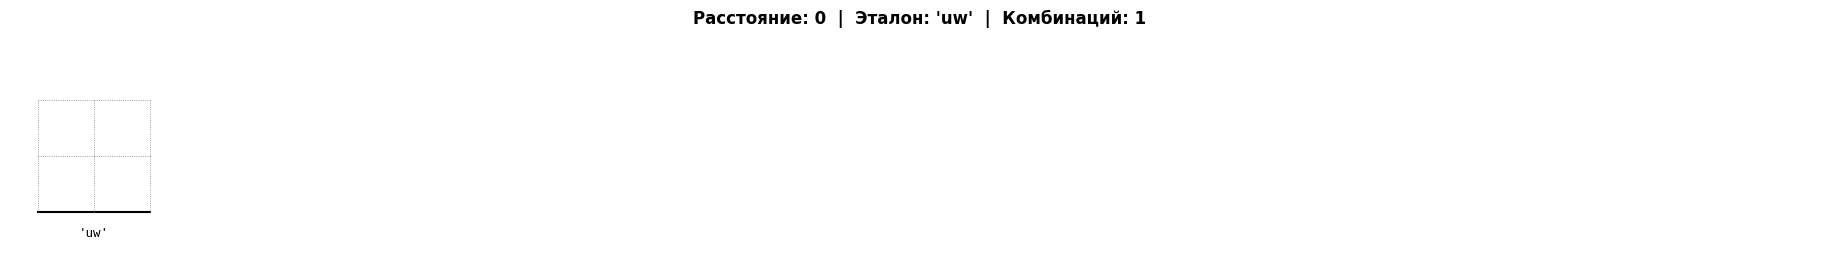

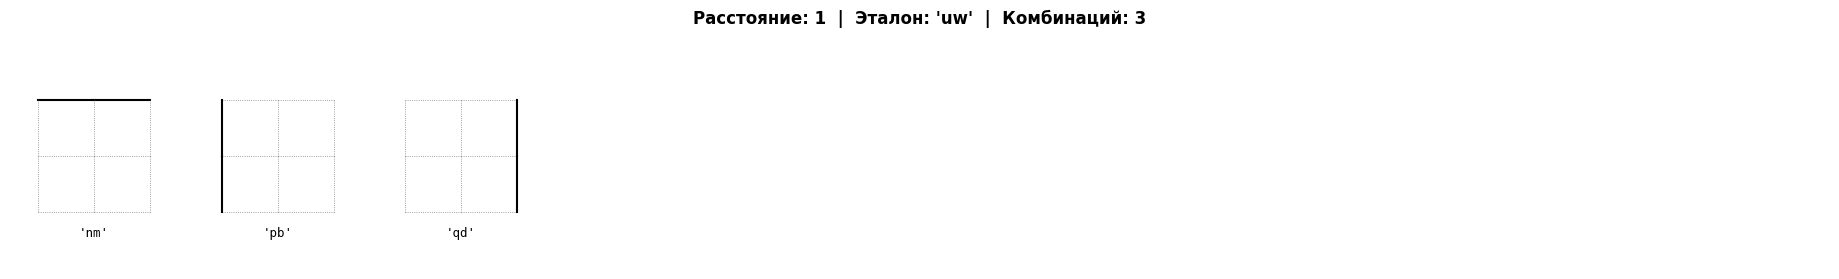

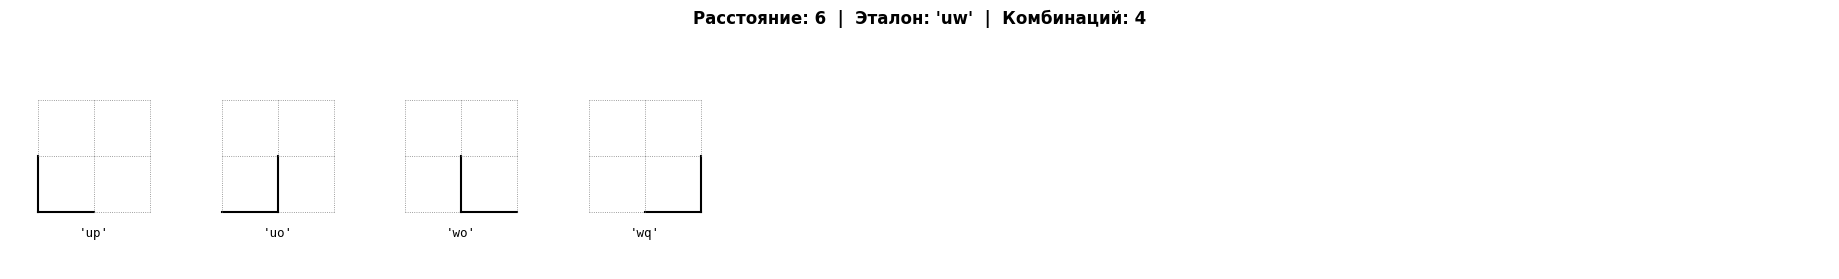

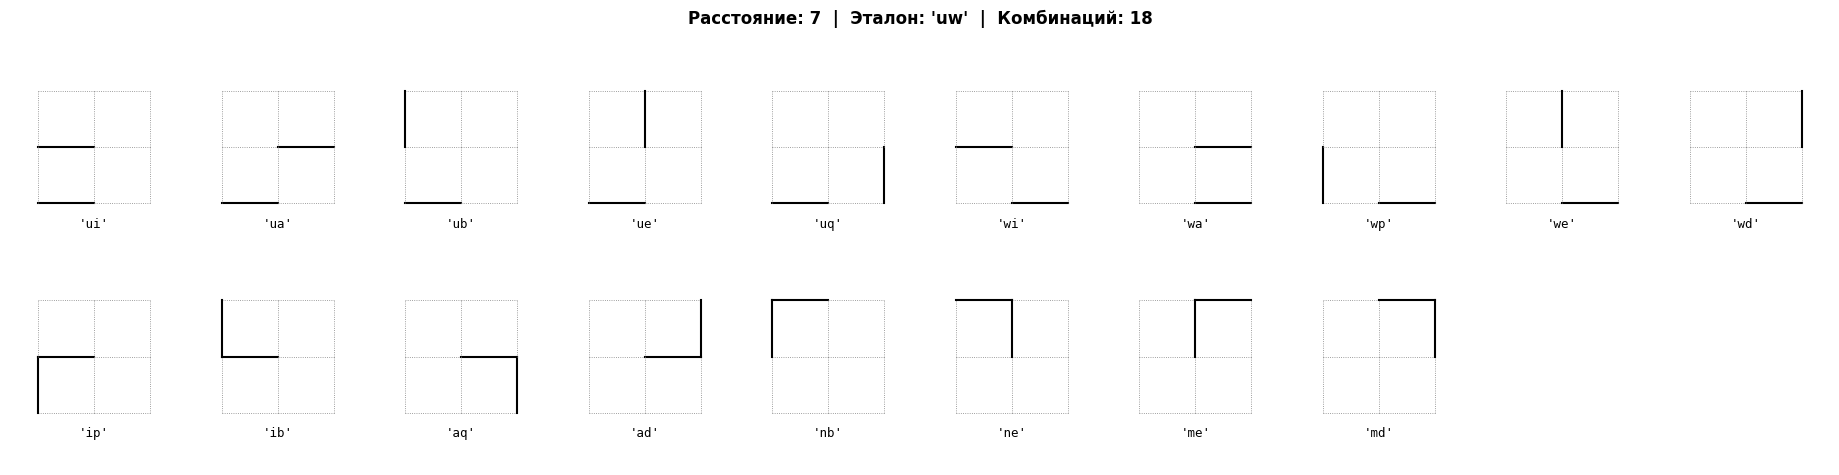

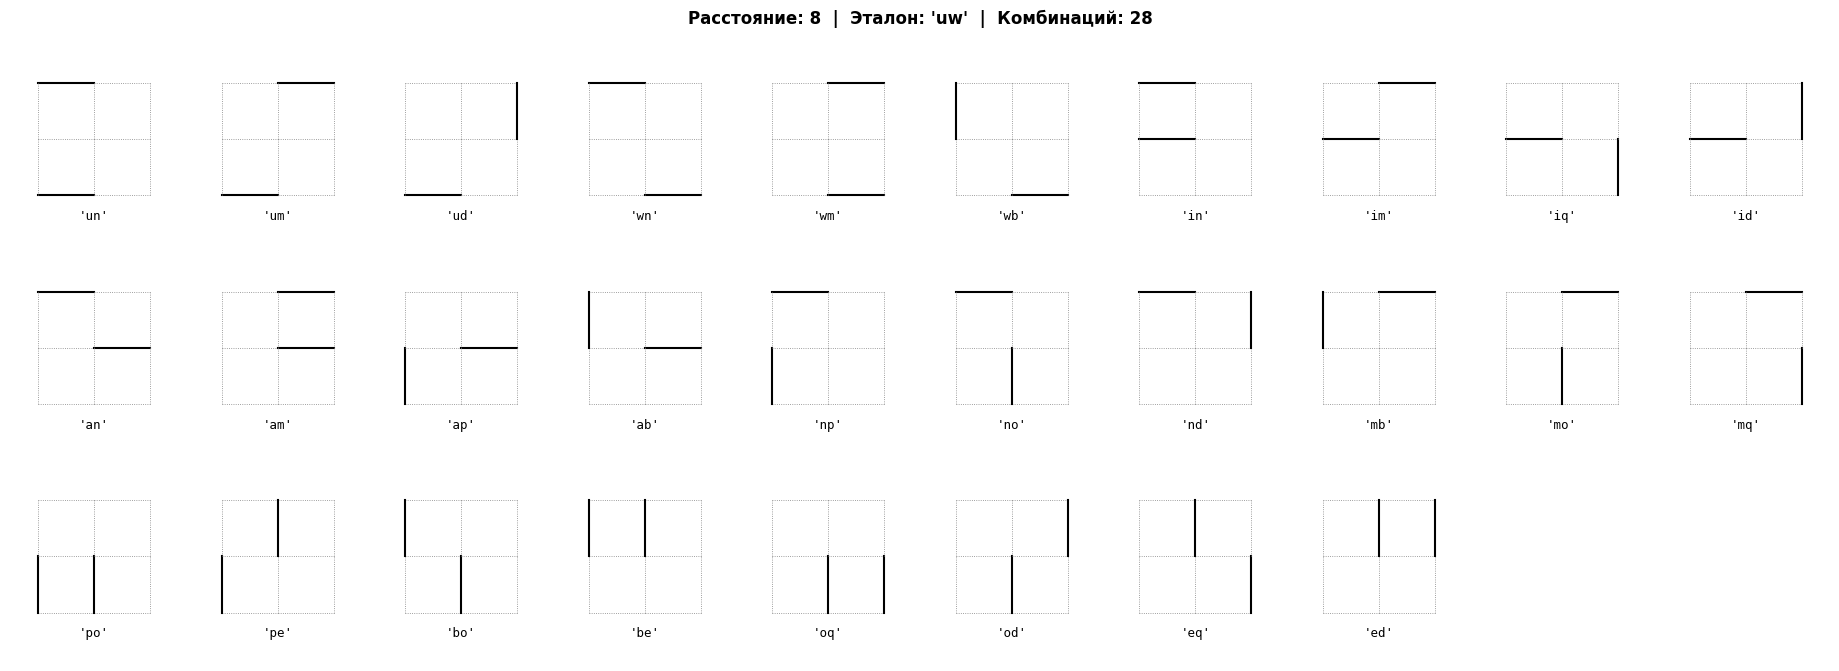

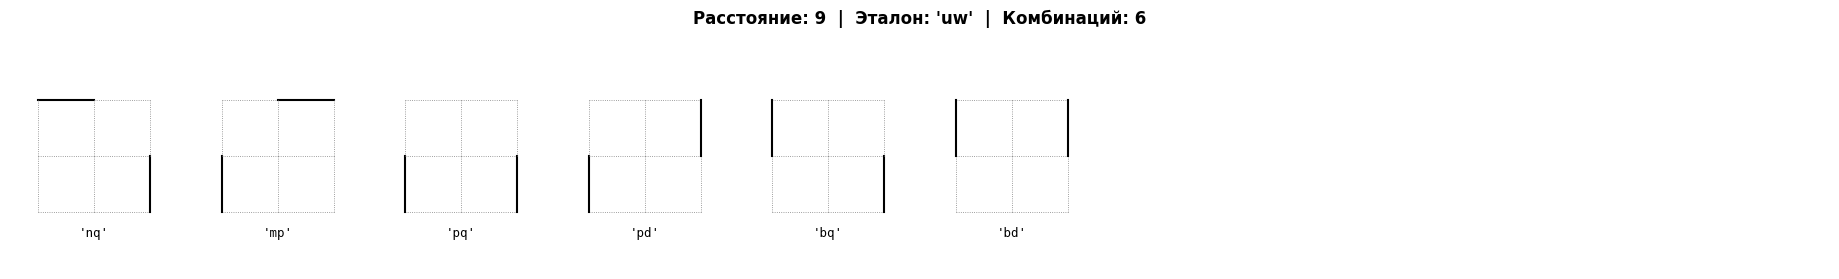

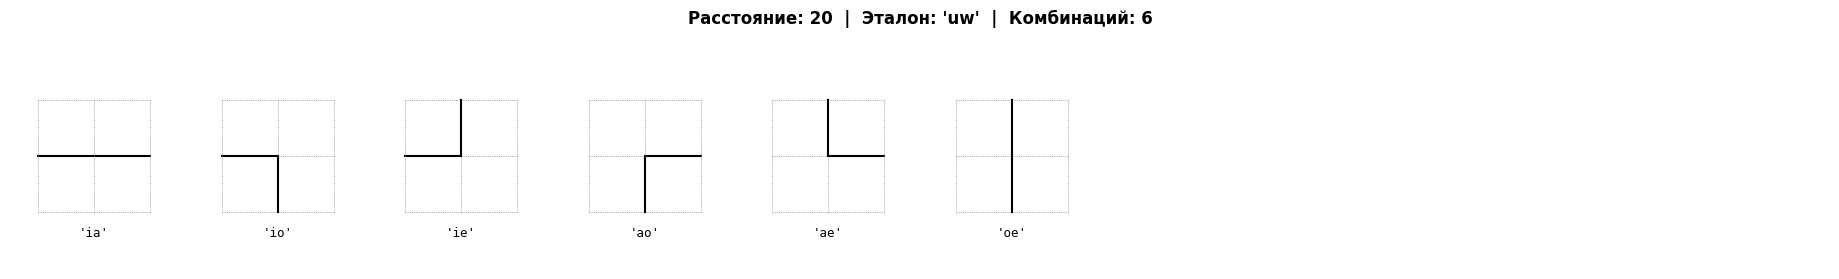

In [10]:
import matplotlib.pyplot as plt


def draw_combo(ax, letter_string, x_offset, y_offset, cell_size=0.6):
    """
    Рисует один квадрат 2×2 с линиями.
    x_offset, y_offset — координаты левого нижнего угла квадрата 2×2.
    cell_size — размер одной ячейки сетки.
    """
    present = decode(letter_string)

    # Масштабируем координаты отрезков
    for i, ((x1, y1), (x2, y2)) in enumerate(EDGES):
        # Смещаем координаты
        xx1 = x_offset + x1 * cell_size
        yy1 = y_offset + y1 * cell_size
        xx2 = x_offset + x2 * cell_size
        yy2 = y_offset + y2 * cell_size

        if i in present:
            ax.plot([xx1, xx2], [yy1, yy2], "k-", linewidth=1.5)
        else:
            ax.plot(
                [xx1, xx2], [yy1, yy2], color="gray", linestyle="dotted", linewidth=0.6
            )

    # Подпись: буквенный код под квадратом
    display_str = "'" + letter_string + "'" if letter_string else "''"
    ax.text(
        x_offset + 1 * cell_size,
        y_offset - 0.15,
        display_str,
        fontsize=9,
        ha="center",
        va="top",
        family="monospace",
    )


def visualize_groups(groups, reference, max_cols=10):
    """
    Для каждой группы расстояний создаёт отдельную фигуру.
    Все фигуры имеют одинаковый масштаб: max_cols столбцов.
    """
    # Фиксированные размеры ячейки (одинаковые для всех групп)
    cell_w = 1.8  # ширина одной ячейки с квадратом
    cell_h = 2.0  # высота одной ячейки с квадратом и подписью

    for dist in sorted(groups.keys()):
        combos = groups[dist]
        n = len(combos)

        # ВСЕГДА используем max_cols столбцов (даже если комбинаций меньше)
        cols = max_cols
        rows = (n + cols - 1) // cols
        if rows == 0:
            rows = 1

        fig_width = cols * cell_w + 0.5
        fig_height = rows * cell_h + 0.8

        fig, axes = plt.subplots(
            rows, cols, figsize=(fig_width, fig_height), squeeze=False
        )

        ref_display = "'" + reference + "'" if reference else "''"
        fig.suptitle(
            f"Расстояние: {dist}  |  Эталон: {ref_display}  |  Комбинаций: {n}",
            fontsize=12,
            fontweight="bold",
        )

        # Рисуем только нужные квадраты, остальные ячейки остаются пустыми
        for idx in range(n):
            r = idx // cols
            c = idx % cols
            ax = axes[r][c]

            # Рисуем квадрат в центре ячейки
            draw_combo(ax, combos[idx], x_offset=0.3, y_offset=0.2)

            # Настройка осей для ячейки
            ax.set_xlim(0, 1.8)
            ax.set_ylim(-0.3, 1.8)
            ax.set_aspect("equal")
            ax.axis("off")

        # Скрываем все неиспользуемые ячейки (включая пустые в последнем ряду)
        for idx in range(rows * cols):
            r = idx // cols
            c = idx % cols
            if idx >= n:
                axes[r][c].axis("off")

        plt.tight_layout()
        plt.show()
        print()  # пустая строка между группами


# =====================================================
# Визуализация groups_uw из ячейки 6
# =====================================================
print("Визуализация групп для эталона 'uw'")
print("=" * 60)

# groups_uw уже вычислен в ячейке 6
visualize_groups(groups_uw, reference_2, max_cols=10)

Сгенерировано комбинаций с 3 буквами: 220

Визуализация групп для эталона 'uwo'


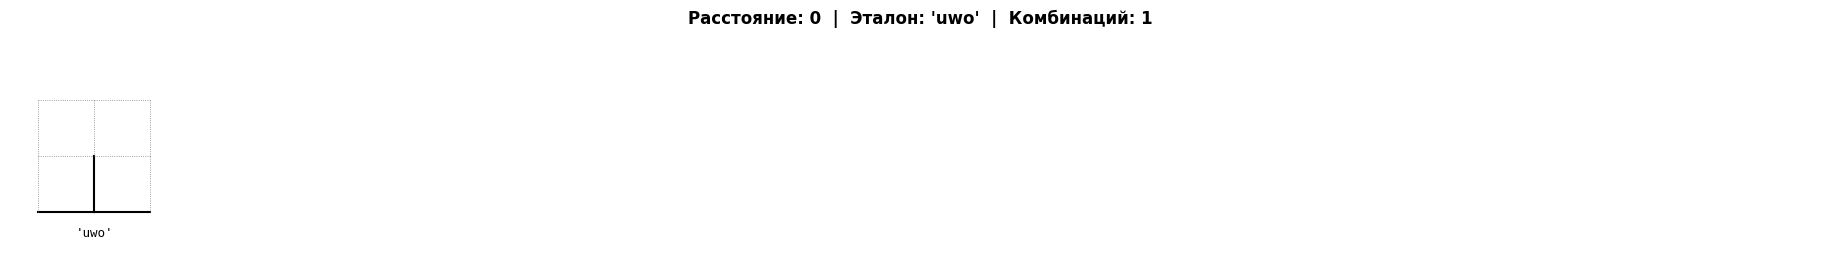

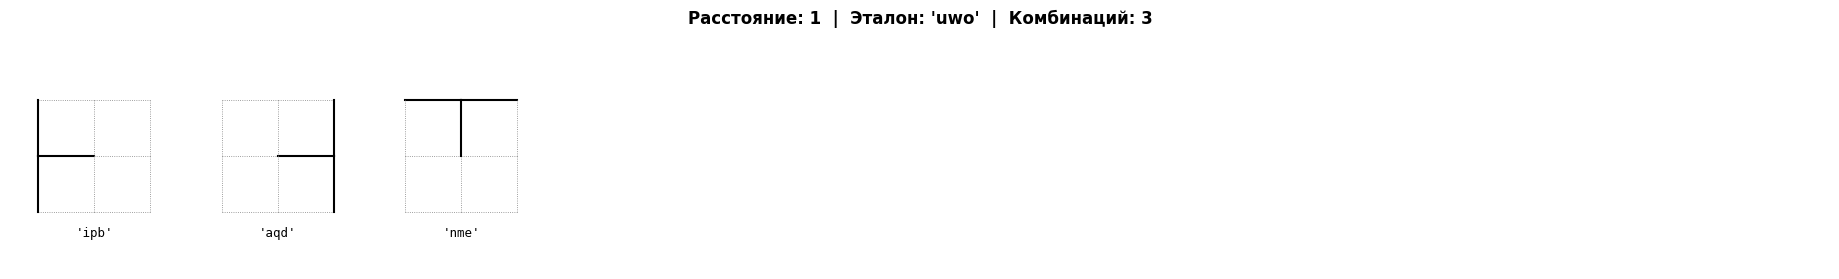

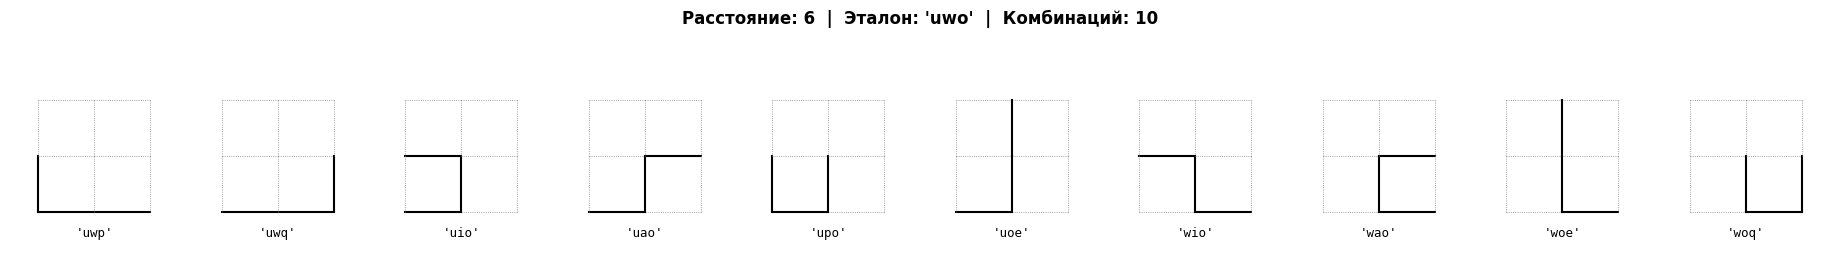

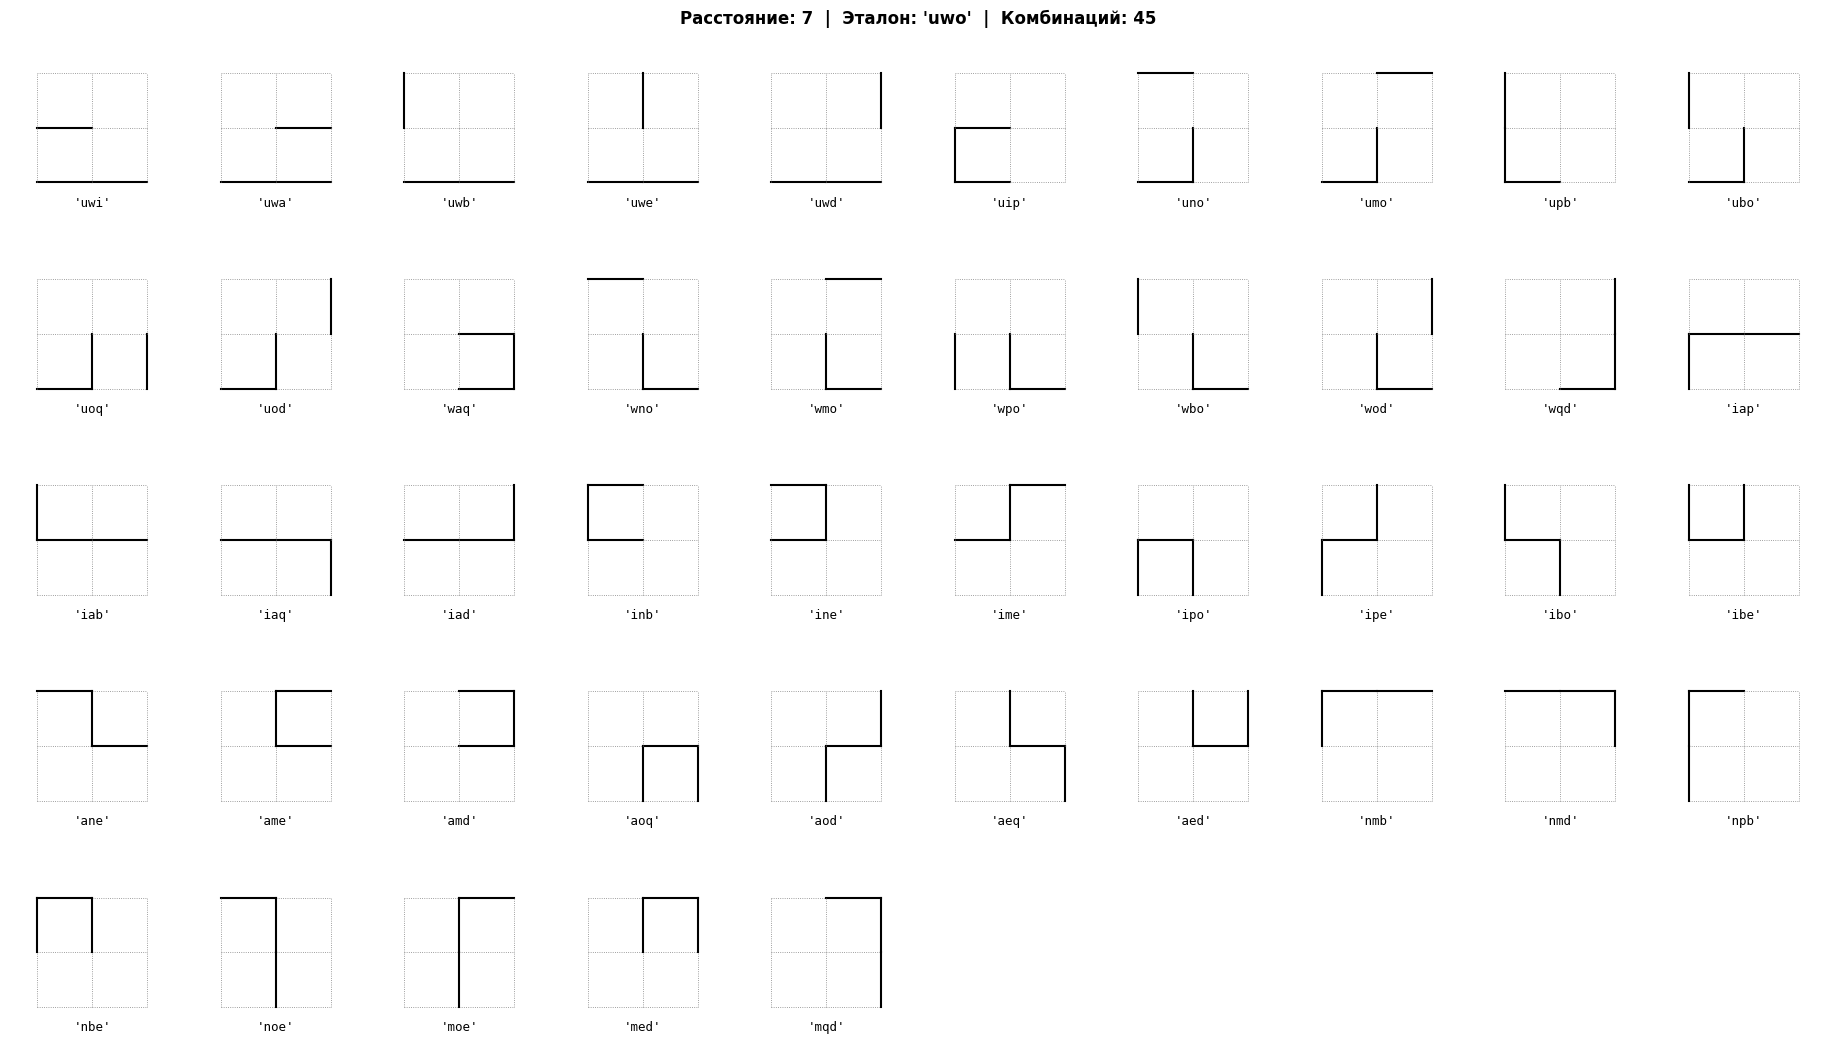

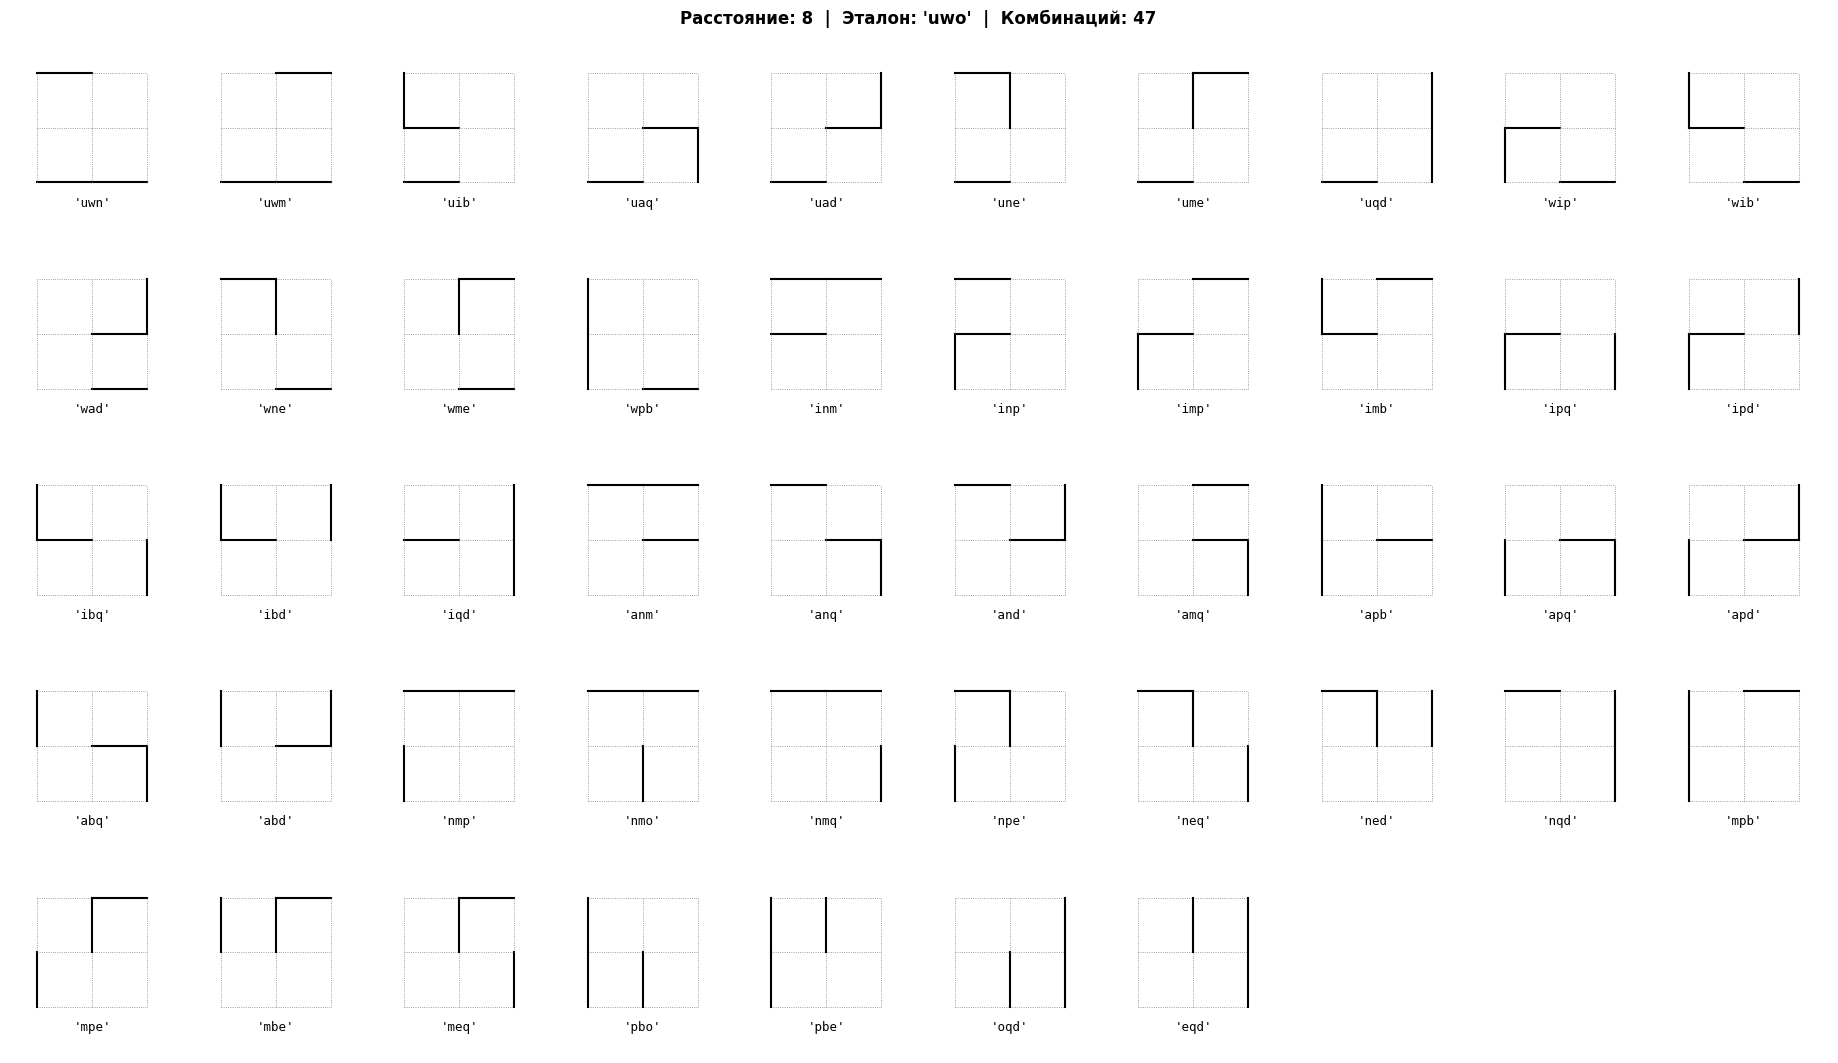

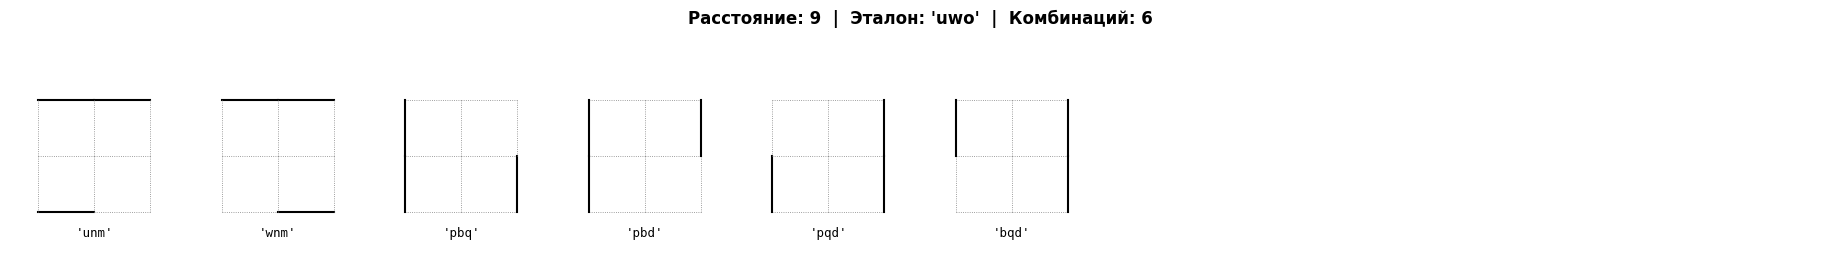

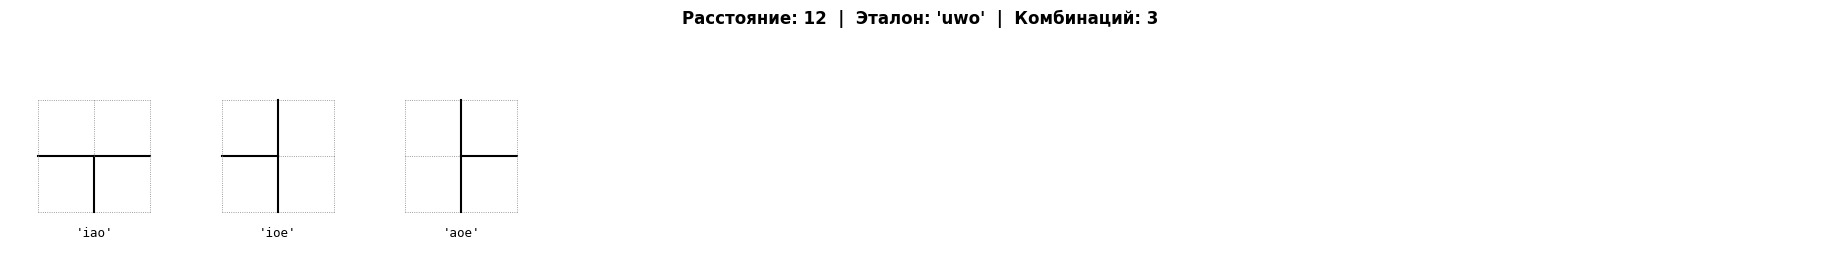

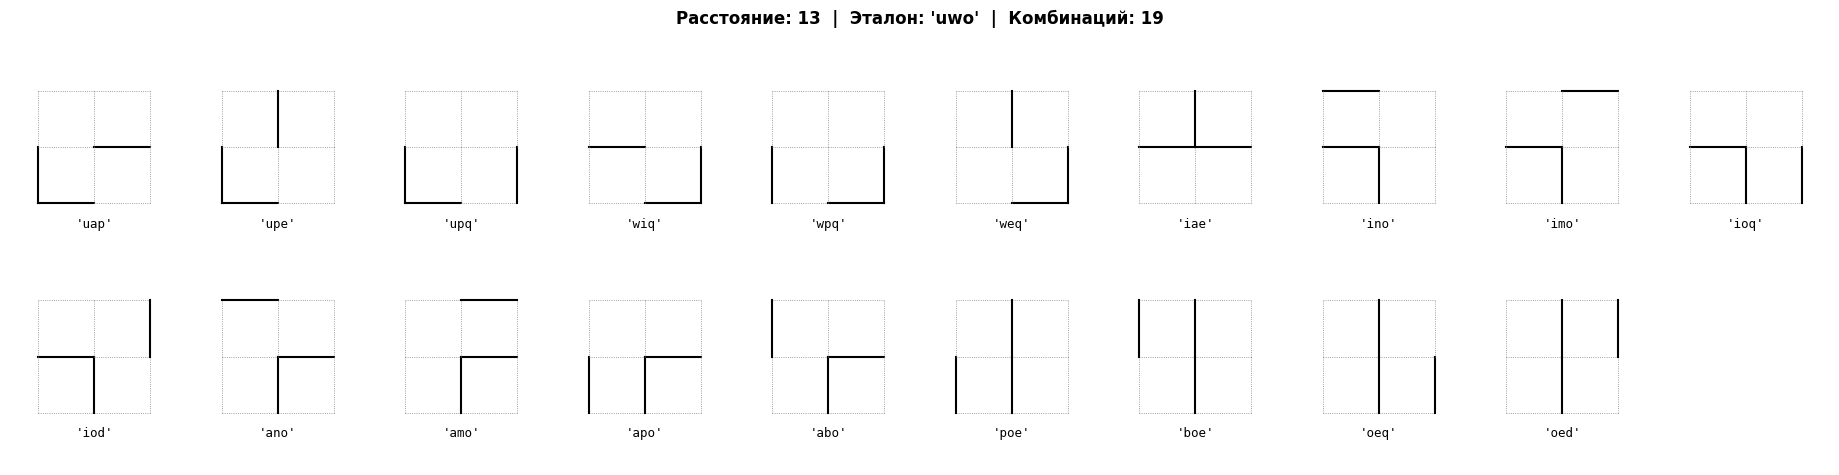

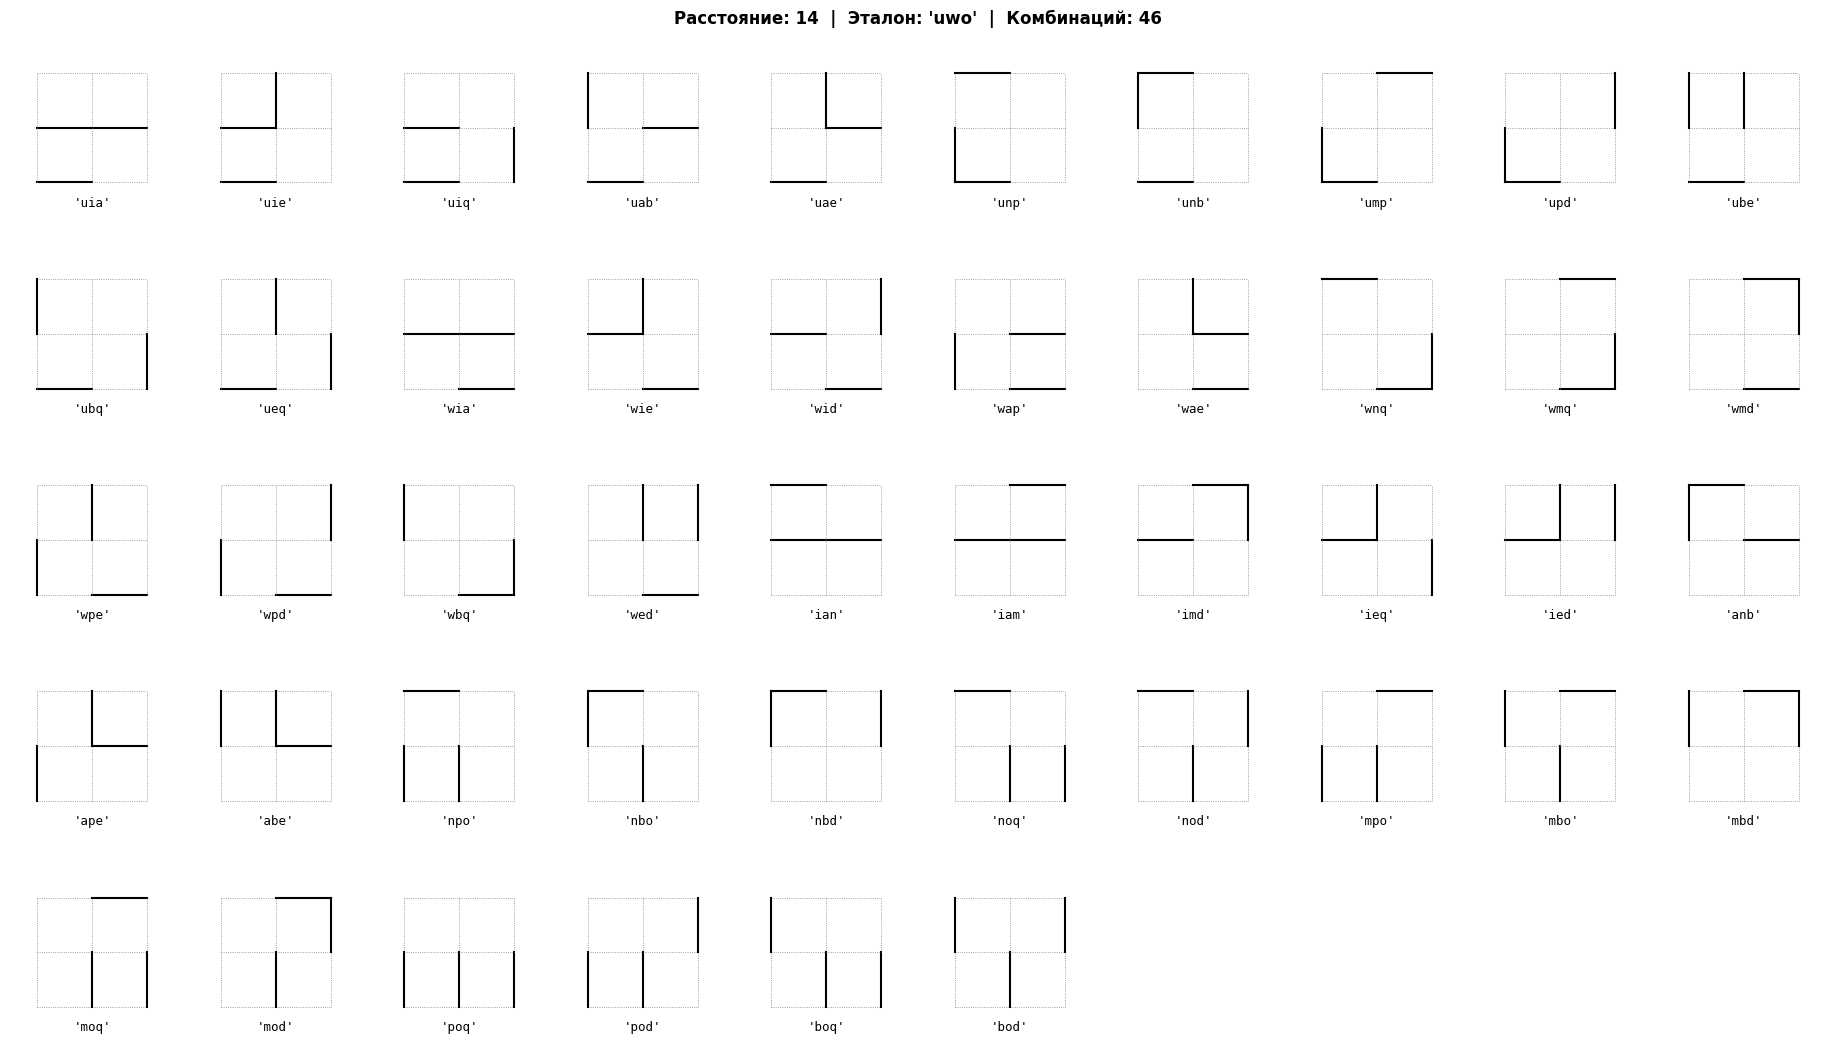

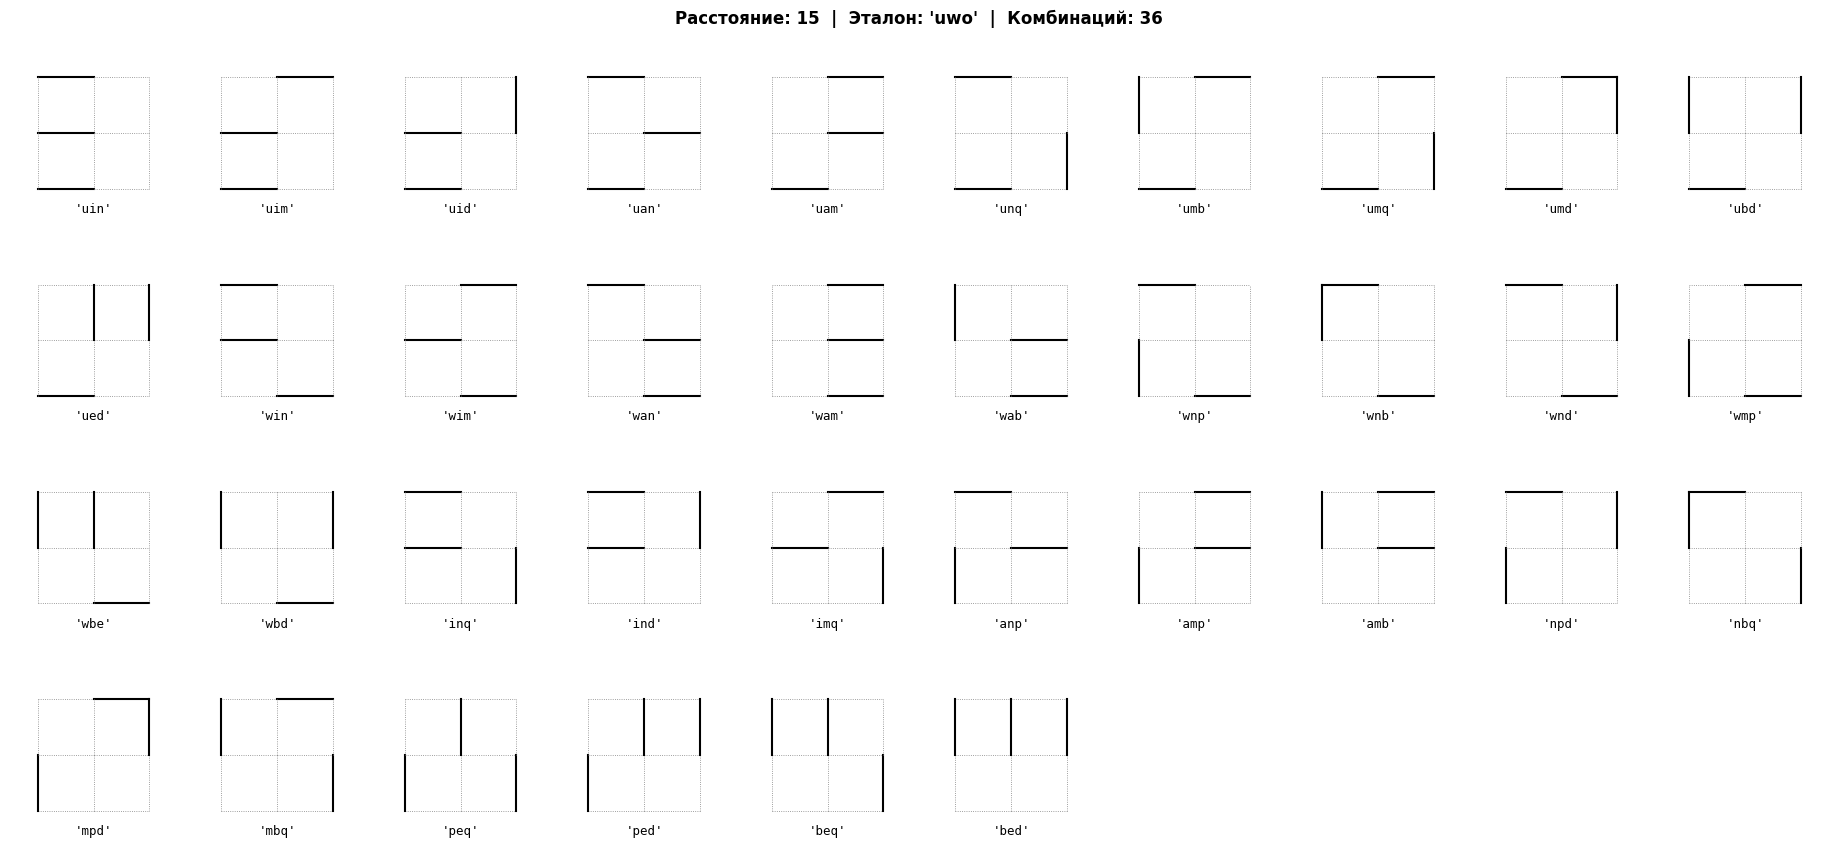

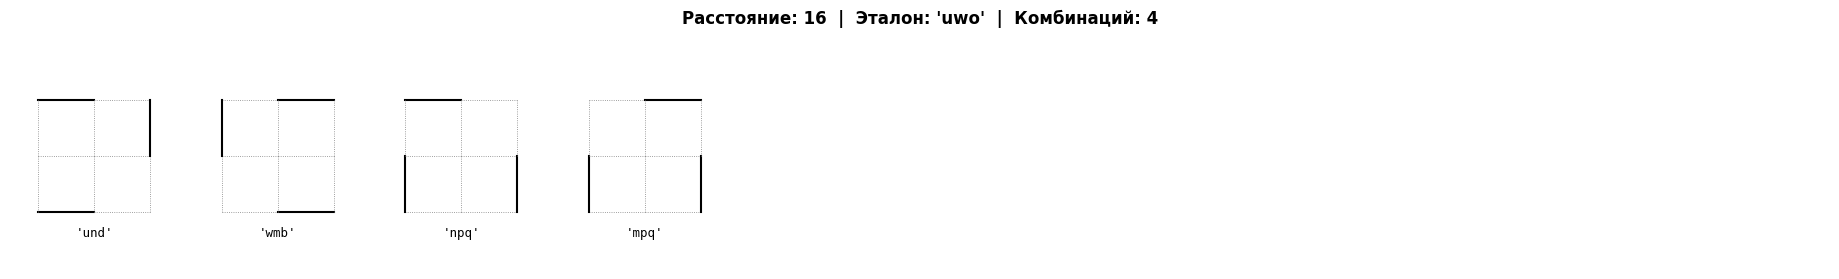

In [12]:
# =====================================================
# Эталон и генерация всех комбинаций с 3 буквами
# =====================================================
reference_3 = "uwo"
samples_3 = generate_all_combinations_letters(3)
print(f"Сгенерировано комбинаций с 3 буквами: {len(samples_3)}")
print()

# =====================================================
# Группировка по расстоянию до эталона
# =====================================================
groups_3 = group_by_distance(reference_3, samples_3)

# =====================================================
# Вывод текстовой группировки
# =====================================================
# print_groups(groups_3, reference_3)

# =====================================================
# Визуализация групп
# =====================================================
print("Визуализация групп для эталона 'uwo'")
print("=" * 60)
visualize_groups(groups_3, reference_3, max_cols=10)